<a href="https://colab.research.google.com/github/AlesioRios/Laboratorio-de-Datos-II/blob/main/Lab_de_Datos_II_TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalar gdown (solo es necesario la primera vez)
#!pip install gdown
# Descargar la carpeta con los datos
!gdown --folder --id 1GOJ63mZ6qZGdbb8v5v6bcy3fsbLs8yju
# Cargar el dataset en un DataFrame
import pandas as pd
df = pd.read_pickle('data/house_prices.pkl')

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Retrieving folder contents
Processing file 1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG data_description.txt
Processing file 1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF house_prices.pkl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1wOLyprsRSgN7TD_MRKKQi_4ts4xdXEAG
To: /content/data/data_description.txt
100% 13.4k/13.4k [00:00<00:00, 23.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ub5YOgvDgOb3WaTeYLs66f3MaPaQ36DF
To: /content/data/house_prices.pkl
100% 140k/140k [00:00<00:00, 4.19MB/s]
Download completed


#Librerias

In [2]:
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats

#Ejercicio 1

##Seccion 1.1

In [3]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")


Dimensiones del dataset: 1487 filas, 14 columnas


Resumen de variables

Las variables corresponden al dataset de Ames Housing (comúnmente usado en la competencia *House Prices* de Kaggle):

* **SalePrice:** Precio de venta de la propiedad en dólares (variable objetivo / target).
* **MSZoning:** Clasificación general de zonificación del terreno (ej. residencial de baja densidad 'RL', residencial de media densidad 'RM', comercial 'C', etc.).
* **Neighborhood:** Ubicación física o barrio dentro de los límites de la ciudad de Ames (ej. `NAmes`, `CollgCr`, `OldTown`).
* **LotFrontage:** Longitud lineal en pies (ft) de la calle conectada con la propiedad (frente del lote).
* **LotArea:** Tamaño total del lote o terreno en pies cuadrados ($ft^2$).
* **OverallCond:** Calificación general del estado/condición de la vivienda en una escala del 1 (muy pobre) al 10 (muy excelente).
* **YearBuilt:** Año original de construcción de la propiedad.
* **FullBath:** Cantidad de baños completos ubicados por encima del nivel del suelo (*above ground*).
* **BedroomAbvGr:** Cantidad de dormitorios ubicados por encima del nivel del suelo (excluye dormitorios en el sótano/basement).
* **GarageQual:** Calidad del garaje (ej. `Ex` Excelente, `Gd` Bueno, `TA` Típico/Promedio, `Fa` Regular, `Po` Pobre, `NA` Sin garaje).
* **GarageArea:** Tamaño total del garaje en pies cuadrados ($ft^2$).
* **PoolArea:** Superficie de la piscina en pies cuadrados ($ft^2$).
* **PoolQC:** Calidad de la piscina (ej. `Ex`, `Gd`, `TA`, `Fa`, `NA` si no tiene piscina).
* **Fence:** Calidad y privacidad de la cerca o cercado (ej. `GdPrv` Buena privacidad, `MnPrv` Mínima privacidad, `GdWo` Buena madera, `MnWw` Mínima madera/alambre, `NA` Sin cerca).


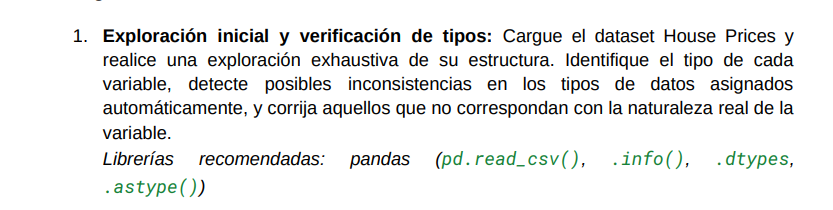

In [4]:
df.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,rL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


In [5]:
def armar_resumen(df):
  """Construye la tabla de resumen de tipos y faltantes, manteniendo
  el % como numérico (para poder aplicarle color o graficarlo después)."""
  resumen = pd.DataFrame({
      'Tipo de Dato': df.dtypes.astype(str),
      'Datos Válidos (No Nulos)': df.notna().sum(),
      'Datos Faltantes (Nulos)': df.isna().sum(),
      '% de Faltantes': (df.isna().sum() / len(df) * 100).round(2),
  })
  return resumen.sort_values(by='Datos Faltantes (Nulos)', ascending=False)


def graficar_faltantes(resumen, umbral=0):
  """Barra horizontal con el % de faltantes por columna, para tener
  una lectura visual rápida antes de entrar al detalle de la tabla.
  umbral filtra columnas con menos de ese % (para no saturar el gráfico
  con columnas que tienen 0 o casi 0 faltantes)."""
  datos = resumen[resumen['% de Faltantes'] > umbral].sort_values('% de Faltantes')
  fig, ax = plt.subplots(figsize=(8, max(3, len(datos) * 0.3)))
  ax.barh(datos.index, datos['% de Faltantes'], color='#D85A30')
  ax.set_xlabel('% de Faltantes')
  ax.set_title('Variables con valores faltantes')
  for i, v in enumerate(datos['% de Faltantes']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
  plt.tight_layout()
  plt.show()


def explorar_categoricas(df, columnas=None, top_n=10):
  """Muestra value_counts de cada columna categórica, para detectar
  inconsistencias de nomenclatura (mayúsculas, espacios, typos) —
  consigna 1.2. Si no se pasan columnas, usa todas las object/category."""
  if columnas is None:
    columnas = df.select_dtypes(include=['object', 'category']).columns
  for col in columnas:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(top_n))
    print()

def graficar_antes_despues_categorias(antes_crudo, despues, orden_final,
                                        categoria_nueva='NONE',
                                        categorias_fusionadas=('NA', 'NAN')):
  """Grafica en dos paneles lado a lado la distribución de una variable
  categórica: a la izquierda, las categorías originales (incluyendo el
  faltante real, mostrado como 'NAN', y la categoría de texto 'NA' por
  separado); a la derecha, la distribución final ya unificada. Resalta
  en color distinto las categorías afectadas por la transformación."""

  normalizado = antes_crudo.astype('string').str.strip().str.upper()
  normalizado = normalizado.fillna('NAN')
  conteo_antes = normalizado.value_counts().sort_values(ascending=False)

  conteo_despues = despues.value_counts().reindex(orden_final, fill_value=0)

  color_normal, color_afectado = '#5F5E5A', '#D85A30'
  colores_antes = [color_afectado if c in categorias_fusionadas else color_normal for c in conteo_antes.index]
  colores_despues = [color_afectado if c == categoria_nueva else color_normal for c in conteo_despues.index]

  fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

  axes[0].barh(conteo_antes.index.astype(str), conteo_antes.values, color=colores_antes)
  axes[0].invert_yaxis()
  axes[0].set_title('Antes: categorías originales')
  axes[0].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_antes.values):
    axes[0].text(v + max(conteo_antes.values) * 0.01, i, str(v), va='center', fontsize=9)

  axes[1].barh(conteo_despues.index.astype(str), conteo_despues.values, color=colores_despues)
  axes[1].invert_yaxis()
  axes[1].set_title('Después: categorías unificadas')
  axes[1].set_xlabel('Cantidad de viviendas')
  for i, v in enumerate(conteo_despues.values):
    axes[1].text(v + max(conteo_despues.values) * 0.01, i, str(v), va='center', fontsize=9)

  plt.tight_layout()
  plt.show()

,Tipo de Dato,Datos Válidos (No Nulos),Datos Faltantes (Nulos),% de Faltantes
PoolQC,object,7,1480,99.53
Fence,object,298,1189,79.96
LotFrontage,float64,1223,264,17.75
GarageQual,object,1411,76,5.11
MSZoning,object,1487,0,0.00
SalePrice,int64,1487,0,0.00
OverallCond,int64,1487,0,0.00
LotArea,int64,1487,0,0.00
Neighborhood,object,1487,0,0.00
YearBuilt,int64,1487,0,0.00


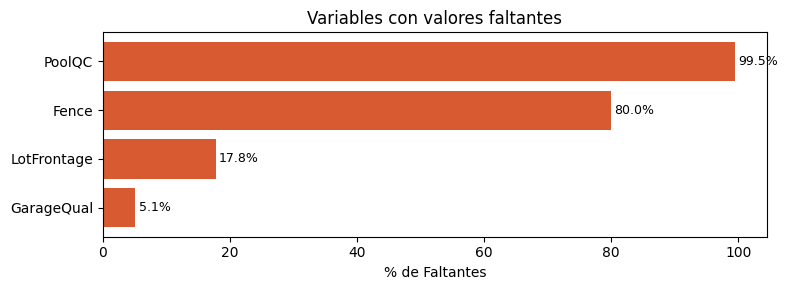

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
0,87500,RL,NAmes,NaN,8544,4,1949,2,2,TA,400,0,NaN,NaN
1,164990,RL,CollgCr,65.0,8767,5,2005,2,3,TA,400,0,NaN,NaN
2,144000,RM,CollgCr,NaN,4435,5,2003,1,1,TA,420,0,NaN,NaN
3,307000,rL,Somerst,75.0,10084,5,2004,2,3,TA,636,0,NaN,NaN
4,130500,RL,Sawyer,NaN,13517,8,1976,2,3,TA,475,0,NaN,NaN


In [6]:
df['SalePrice'] = df['SalePrice'].astype(int)
df['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')

#Chequeamos que son int64 y float64 respectivamente
assert df['SalePrice'].dtype == 'int64'
assert df['LotFrontage'].dtype == 'float64'

resumen = armar_resumen(df)

display(resumen)
graficar_faltantes(resumen, umbral=0)
df.head()


Despues de realizar un analisis de la estructura del dataset y los tipos de datos para cada variable, podemos agruparlas de la siguiente manera:

**Numericas**

Enteros:


*   SalePrice
* LotArea
* YearBuilt
* BedroomAbvGR
* FullBath
* PoolArea
* GarageArea
* LotFrontage (en todos los registros, la parte decimal es 0)

**Categoricas**

Nominales:
*   NeighborHood
*   MSZoning

Ordinales:
*   OverallCond (codificada numericamente)
* GarageQual
* PoolQC
* Fence








##Seccion 1.2

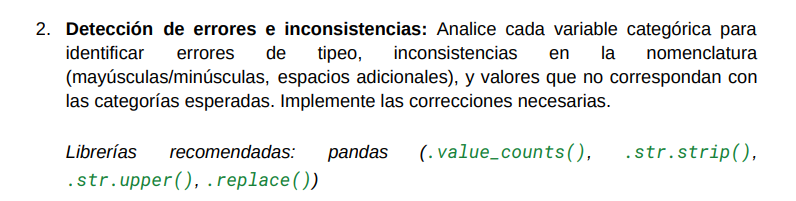

In [7]:
#PoolQC

df_antes = df.copy()
print(df_antes['PoolQC'].value_counts(dropna=False))

#Podemos ver que esta variable no parece tener ninguna inconsistencia en los resgistros cargados
#Sin emabrgo, dado que los NaN representan casas sin piletas, para mantener una consistencia en el dataset los rellenaremos con NONE

df['PoolQC'] = df['PoolQC'].fillna('NONE')
print('\n')
df['PoolQC'].value_counts(dropna=False)



PoolQC
NaN    1480
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64




,count
PoolQC,
NONE,1480
Gd,3
Ex,2
Fa,2


In [8]:
#Fence

df['Fence'].value_counts(dropna = False)

#En esta variable vemos que hay dos registros que se refieren a lo mismo (Nan y nan). Por eso primero vamos a juntarlos todos con el mismo nombre, ya
#que ambos hacen referencia a casas que no tienen un cercado y despues les pondremos el nombre 'NONE' para mantener la consistencia en el dataset



,count
Fence,
NaN,1189
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11
nan,10


In [9]:
df['Fence'] = df['Fence'].fillna('NONE')
print('\n')
df['Fence'].value_counts(dropna=False)

#Al reemplazar todos los valores faltantes por 'NONE' ocurre algo interesante que es que los registros con 'nan' no se rellenaron
#Esto se debe a que probablemente tengan espacios en blanco y por eso el metodo fillna no los detecte

,count
Fence,
NONE,1189
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11
nan,10


In [10]:
#Eliminamos espacios en blanco y volvemos a probar
df['Fence']  = df['Fence'].str.strip()

#Comprobamos que realmente se tratan de cadenas de texto y no de valores nulos reales
df_filtrado = df[df['Fence'] == 'nan']

df_filtrado.head()

,SalePrice,MSZoning,Neighborhood,LotFrontage,LotArea,OverallCond,YearBuilt,FullBath,BedroomAbvGr,GarageQual,GarageArea,PoolArea,PoolQC,Fence
220,131500,RM,CollgCr,36.0,4435,5,2003,1,1,TA,420,0,NONE,nan
327,135000,RL,Edwards,60.0,8172,6,1954,2,4,TA,548,0,NONE,nan
356,149900,RL,Edwards,134.0,17755,4,1959,1,3,TA,528,0,NONE,nan
503,87000,RM,IDOTRR,50.0,5000,6,1941,1,2,TA,360,0,NONE,nan
789,133000,Rh,NAmes,34.0,4058,5,1998,1,1,TA,367,0,NONE,nan


In [11]:
#Ahora si reemplazamos y unificamos
df['Fence'] = df['Fence'].replace({'nan' : 'NONE'})
df['Fence'].value_counts()

,count
Fence,
NONE,1199
MnPrv,161
GdPrv,62
GdWo,54
MnWw,11


In [12]:
#Neighborhood
print('Frecuencias originales:')
print(df['Neighborhood'].value_counts())

#Al comparar los resultados con la documentacion oficial del dataset, todos los registros estan correctos excepto dos. Al final de la lista se repiten
#'NAmes' y 'BrkSide'

#Verificamos si hay algun espacio en blanco
df['Neighborhood']  = df['Neighborhood'].str.strip()
print('\nFrecuencias despues de aplicar str.strip():')
df['Neighborhood'].value_counts()

#Podemos comprobar que efectivamente los 3 registros adicionales se debian a la presencai de espacios en blanco en los registros, por lo que ya estan bien unificados

Frecuencias originales:
Neighborhood
NAmes        225
CollgCr      156
OldTown      114
Edwards      102
Somerst       87
Gilbert       81
NridgHt       78
NWAmes        77
Sawyer        75
SawyerW       60
BrkSide       57
Crawfor       51
Mitchel       50
NoRidge       42
Timber        38
IDOTRR        37
ClearCr       28
SWISU         26
StoneBr       25
MeadowV       18
Blmngtn       18
BrDale        17
Veenker       11
NPkVill        9
Blueste        2
 NAmes         2
 BrkSide       1
Name: count, dtype: int64

Frecuencias despues de aplicar str.strip():


,count
Neighborhood,
NAmes,227
CollgCr,156
OldTown,114
Edwards,102
Somerst,87
Gilbert,81
NridgHt,78
NWAmes,77
Sawyer,75


In [13]:
#MSZoning

df['MSZoning'].value_counts()

#Comparando con la documentacion oficial, todos los registros tendrian que estar en mayuscula. Sin embargo, en el dataset hay registros que hacen referencia
# a las zonas correctas pero escritas en minuscula


,count
MSZoning,
RL,1168
RM,222
FV,66
C (all),10
Rh,10
RH,6
rL,5


In [14]:
#Ponemos todo en mayusculas
df['MSZoning'] = df['MSZoning'].str.upper()

df['MSZoning'].value_counts()

,count
MSZoning,
RL,1173
RM,222
FV,66
RH,16
C (ALL),10


,count
GarageArea,
0,76


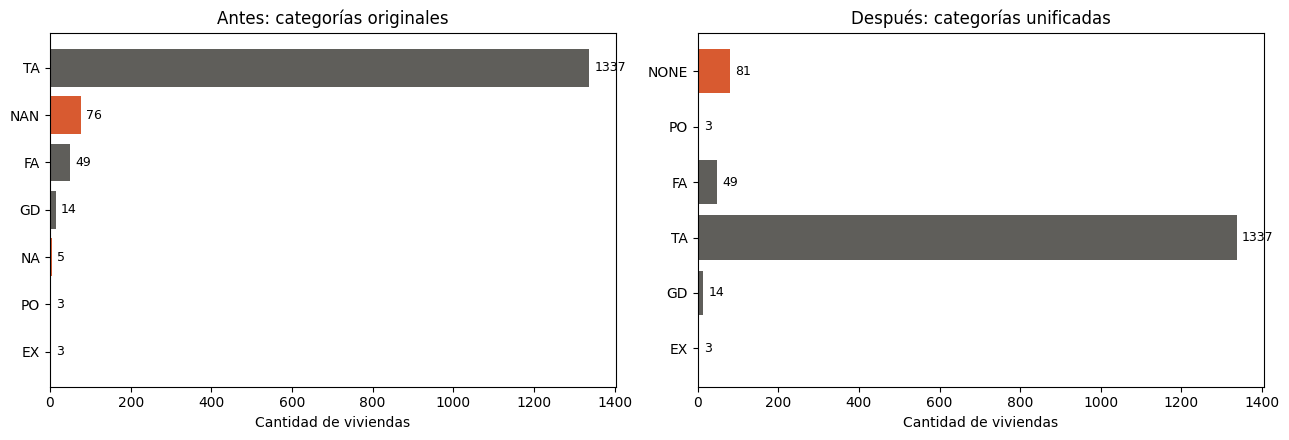

In [15]:
#GarageQual

df_antes = df['GarageQual'].copy()
df['GarageQual'].value_counts(dropna=False)
#Se puede observar que hay una falsa categoría: NaN y NA porbablemente hagan referencia a la clase "Na": que no tiene garage.
#Estrategia adoptadas: pasamos todo a mayúsculas, y fusionamos estas dos categorías.
df['GarageQual'] = df['GarageQual'].str.strip().str.upper() # strip() elimina espacios en blanco al principio y al final de cada texto.
#Vamos a determinar si los NaN son faltantes o si hacen referencia a la categoría "Na"
display(df.loc[df['GarageQual'].isna(), 'GarageArea'].value_counts()) #Podemos ver que todos los NaN de GarageQual eran en realidad "Na" (o indica que no hay garage)

sin_garage = df['GarageArea'] == 0
df.loc[sin_garage, 'GarageQual'] = 'NONE'
df['GarageQual'] = df['GarageQual'].replace({'NA': 'NONE'})

orden_calidad_Grid = CategoricalDtype(categories = ['NONE', 'PO', 'FA', 'TA', 'GD', 'EX'], ordered = True)
df['GarageQual'] = df['GarageQual'].astype(orden_calidad_Grid)
assert df['GarageQual'].isna().sum() == 0, "Quedaron valores sin mapear al hacer el cast"

graficar_antes_despues_categorias(antes_crudo=df_antes, despues=df['GarageQual'], orden_final=['NONE', 'PO', 'FA', 'TA', 'GD', 'EX'])

In [16]:
variable = df['SalePrice']
print(variable)

0        87500
1       164990
2       144000
3       307000
4       130500
         ...  
1482    270000
1483    109008
1484    102000
1485    165000
1486     81000
Name: SalePrice, Length: 1487, dtype: int64


##Seccion 1.3

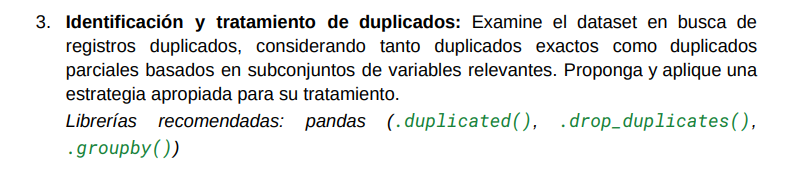

In [ ]:
#Evaluamos cuantos registros estan duplicados

cant_filas_duplicadas = df.duplicated().sum()
print(f'Cantidad de filas duplicadas: {cant_filas_duplicadas}')
# Filtrar el DataFrame para conservar todas las filas duplicadas


duplicados = df[df.duplicated(keep=False)]
frecuencia_duplicados = (
    duplicados
    .groupby(list(df.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
)

frecuencia_duplicados


len(duplicados)
#frecuencia_duplicados['frecuencia'].value_counts()

In [ ]:
duplicados_ordenados = duplicados.sort_values(
    by=list(df.columns)
)

duplicados_ordenados

Como primer paso se verificó la existencia de registros duplicados mediante df.duplicated(). Se identificaron 24 registros duplicados respecto de una aparición anterior. Al utilizar keep=False, se observó que existen 48 observaciones involucradas, correspondientes a 24 pares de filas idénticas.
Además, se comprobó que todos los grupos tienen una frecuencia de 2, es decir, no existen combinaciones que aparezcan tres o más veces.

A continuación, se decidió investigar si determinadas variables presentaban coincidencias parciales particularmente relevantes.

La idea no fue simplemente buscar las variables cuyos valores aparecen más veces, sino identificar aquellas que poseen una mayor capacidad discriminativa entre viviendas.

Una variable es más interesante para este análisis cuando sus valores representan características relativamente específicas de una propiedad. Por el contrario, variables con pocos valores posibles, como una escala de calidad o una cantidad reducida de categorías, pueden presentar muchas repeticiones simplemente por su naturaleza.

Por este motivo, se decidió analizar progresivamente diferentes grupos de variables, desde características físicas más específicas hacia características estructurales y contextuales.

In [ ]:
#Variables de cada nivel
variables_nivel_1 = [
    'LotFrontage',
    'LotArea',
    'GarageArea'
]

variables_nivel_2 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond'
]

variables_nivel_3 = [
    'LotFrontage',
    'LotArea',
    'GarageArea',
    'YearBuilt',
    'OverallCond',
    'Neighborhood',
    'SalePrice'
]


#Función para obtener las frecuencias de los grupos duplicados
def obtener_frecuencias(df, variables):
    frecuencias = (df.groupby(variables, dropna=False).size())
    frecuencias = frecuencias[frecuencias > 1]
    return frecuencias.value_counts().sort_index()


#Obtener distribución de frecuencias para cada nivel
freq_nivel_1 = obtener_frecuencias(df, variables_nivel_1)
freq_nivel_2 = obtener_frecuencias(df, variables_nivel_2)
freq_nivel_3 = obtener_frecuencias(df, variables_nivel_3)


#Unir los tres niveles
tabla_frecuencias = pd.concat(
    [freq_nivel_1, freq_nivel_2, freq_nivel_3], axis=1)

tabla_frecuencias.columns = ['Nivel 1', 'Nivel 2', 'Nivel 3']
tabla_frecuencias = tabla_frecuencias.fillna(0)

In [ ]:
ax = tabla_frecuencias.plot(
    kind='bar',
    figsize=(10, 4),
    width=0.8
)

plt.xlabel('Frecuencia de repetición')
plt.ylabel('Cantidad de grupos')
plt.title('Evolución de los grupos duplicados por nivel')
plt.xticks(rotation=0)
plt.legend(title='Nivel')

plt.tight_layout()
plt.show()

Nivel 1 — Características físicas:
Al analizar coincidencias utilizando dimensiones físicas concretas de una propiedad, se encontraron grupos con frecuencias de repetición de hasta 8 observaciones. Esto muestra que varias viviendas pueden compartir simultáneamente determinadas características, por lo que una coincidencia parcial no resulta suficiente para considerarlas duplicados.

Nivel 2 — Características estructurales:
Al incorporar información adicional relacionada con las características estructurales de las viviendas, las coincidencias disminuyeron considerablemente. Los grupos de mayor frecuencia desaparecieron y la máxima frecuencia pasó a ser 3. Esto indica que parte de las coincidencias observadas inicialmente podían diferenciarse al considerar información adicional.

Nivel 3 — Contexto y precio:
Finalmente, al incorporar información contextual y el precio de venta, todas las coincidencias restantes quedaron reducidas a pares. Esto evidencia que, a medida que se incorporan variables adicionales, aumenta la capacidad de distinguir entre observaciones que inicialmente parecían duplicadas.

En conclusion el análisis no permite determinar de manera definitiva si los 24 pares corresponden a la misma vivienda registrada dos veces o a viviendas diferentes que coinciden en todas las variables disponibles.

Esto es especialmente relevante porque se trabaja con un subconjunto reducido de variables y no se dispone de un identificador único de la propiedad ni del dataset original para contrastar las observaciones.

En consecuencia, y ante la ausencia de evidencia suficiente para afirmar que se trata de errores de carga o duplicaciones accidentales, se decidió conservar los 48 registros involucrados en los pares duplicados.

La decisión evita eliminar observaciones potencialmente válidas basándose únicamente en la igualdad de las variables disponibles.

#Ejercicio 2

##Seccion 2.1


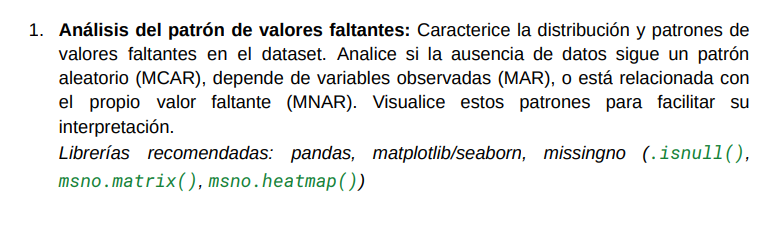

borrador de mili, ignorar.

In [ ]:
#saleprice
variable = 'SalePrice'
"""
# 2. Calculamos los cuartiles y el Rango Intercuartílico (IQR)
Q1 = df[variable].quantile(0.25)
Q3 = df[variable].quantile(0.75)
IQR = Q3 - Q1

# 3. Calculamos los límites inferior y superior permitidos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Generamos el gráfico de caja y bigotes
plt.figure(figsize=(10, 2))
sns.boxplot(x=df[variable], color='skyblue')
plt.title(f'Distribución de {variable} (Boxplot)')
plt.xlabel('Precio de Venta')
plt.show()
"""
# 5. Filtramos el DataFrame original para quedarnos solo con los outliers
outliers_df = df[(df[variable] < 40000) | (df[variable] > 500000)]

# 6. Imprimimos el resultado
print(SalePrice)
display(outliers_df)

##Seccion 2.2

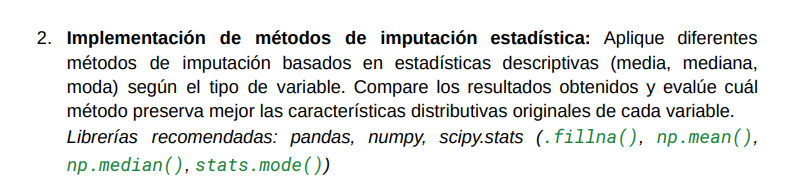

##Seccion 2.3

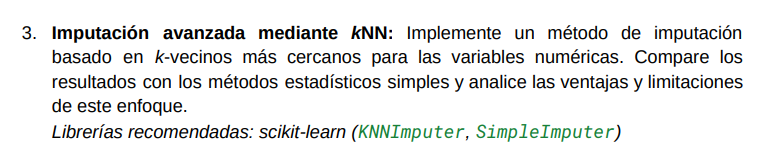

In [ ]:
#Primero hacemos un heatmap para indicar las variables mas correlacionadas con la de interes para que el knn
#pueda usarlas para imputar correctamente

df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()

#Generar una máscara booleana para el triángulo superior (incluye la diagonal)
mascara = np.triu(np.ones_like(correlacion, dtype=bool), k = 1)

plt.figure(figsize=(10, 5))

sns.heatmap(
    correlacion,
    mask=mascara,
    cmap='coolwarm',       # Escala divergente: rojo (positiva), azul (negativa)
    annot=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlación de Variables Numéricas (House Prices)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


De esta manera, seleccionamos GarageArea, BedroomAbvGr y PoolArea

In [ ]:
#Imputacion por KNN para la variable LotFrontage

columnas_knn = ['LotFrontage', 'GarageArea', 'PoolArea', 'BedroomAbvGr']
df_knn = df[columnas_knn].copy()

#Aplicamos KNNImputer
imputador_knn = KNNImputer(n_neighbors=5) #usamos la cantidad estandar de la funcion
df_imputado_array = imputador_knn.fit_transform(df_knn)

#Reconstruimos un DataFrame temporal con los datos imputados para graficar
df_imputado = pd.DataFrame(df_imputado_array, columns=columnas_knn)

#Gráfico de densidad superpuesto (KDE)
plt.figure(figsize=(10, 6))

#Distribución original ignorando los valores nulos (dropna)
sns.kdeplot(df['LotFrontage'].dropna(),
            label='Original (Ignorando NaNs)',
            color='blue',
            linewidth=2)

#Distribución con los valores imputados por KNN
sns.kdeplot(df_imputado['LotFrontage'],
            label='Imputado (KNN, k=5)',
            color='orange',
            linestyle='--',
            linewidth=2)

plt.title('Distribución de LotFrontage: Original vs KNN Imputer')
plt.xlabel('LotFrontage (Pies lineales de calle)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

EL KNN ES CLAVE

#Ejercicio 3

##Seccion 3.1

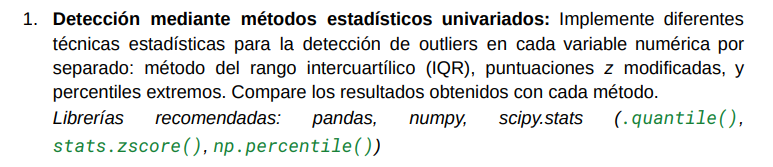

SalePrice

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['SalePrice'].quantile(0.25)
q3 = df['SalePrice'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['SalePrice'].quantile(0.01)
p_sup = df['SalePrice'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['SalePrice'].median()
mad = stats.median_abs_deviation(df['SalePrice'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['SalePrice'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en SalePrice', fontsize=13)
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotFrontage

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotFrontage'].quantile(0.25)
q3 = df['LotFrontage'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotFrontage'].quantile(0.01)
p_sup = df['LotFrontage'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotFrontage'].median()
mad = stats.median_abs_deviation(df['LotFrontage'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['LotFrontage'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotFrontage', fontsize=13)
plt.xlabel('LotFrontage')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

LotArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['LotArea'].quantile(0.25)
q3 = df['LotArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['LotArea'].quantile(0.01)
p_sup = df['LotArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['LotArea'].median()
mad = stats.median_abs_deviation(df['LotArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['LotArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en LotArea', fontsize=13)
plt.xlabel('LotArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

YearBuilt

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['YearBuilt'].quantile(0.25)
q3 = df['YearBuilt'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['YearBuilt'].quantile(0.01)
p_sup = df['YearBuilt'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['YearBuilt'].median()
mad = stats.median_abs_deviation(df['YearBuilt'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['YearBuilt'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en YearBuilt', fontsize=13)
plt.xlabel('YearBuilt')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

FullBath



In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['FullBath'].quantile(0.25)
q3 = df['FullBath'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['FullBath'].quantile(0.01)
p_sup = df['FullBath'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['FullBath'].median()
mad = stats.median_abs_deviation(df['FullBath'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['FullBath'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en FullBath', fontsize=13)
plt.xlabel('FullBath')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

BedroomAbvGr

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['BedroomAbvGr'].quantile(0.25)
q3 = df['BedroomAbvGr'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['BedroomAbvGr'].quantile(0.01)
p_sup = df['BedroomAbvGr'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['BedroomAbvGr'].median()
mad = stats.median_abs_deviation(df['BedroomAbvGr'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['BedroomAbvGr'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en BedroomAbvGr', fontsize=13)
plt.xlabel('BedroomAbvGr')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

GarageArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['GarageArea'].quantile(0.25)
q3 = df['GarageArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['GarageArea'].quantile(0.01)
p_sup = df['GarageArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['GarageArea'].median()
mad = stats.median_abs_deviation(df['GarageArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['GarageArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en GarageArea', fontsize=13)
plt.xlabel('GarageArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

PoolArea

In [ ]:
#Cálculo de umbrales
#IQR
q1 = df['PoolArea'].quantile(0.25)
q3 = df['PoolArea'].quantile(0.75)
iqr = q3 - q1
iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

#Percentiles 1 y 99
p_inf = df['PoolArea'].quantile(0.01)
p_sup = df['PoolArea'].quantile(0.99)

#Z-score modificado (umbral = 3.5)
mediana = df['PoolArea'].median()
mad = stats.median_abs_deviation(df['PoolArea'].dropna())
zmod_inf = mediana - (3.5 * mad) / 0.6745
zmod_sup = mediana + (3.5 * mad) / 0.6745

#Gráfico
plt.figure(figsize=(12, 6))
sns.histplot(df['PoolArea'], kde=True, color='lightgray', bins=50, edgecolor='black')

plt.axvline(iqr_inf, color='crimson', linestyle='--', linewidth=2, label='IQR (1.5)')
plt.axvline(p_inf, color='darkorange', linestyle=':', linewidth=2, label='Percentiles (1% - 99%)')
plt.axvline(zmod_inf, color='navy', linestyle='-.', linewidth=2, label='Z-modificado (3.5)')

plt.axvline(iqr_sup, color='crimson', linestyle='--', linewidth=2)
plt.axvline(p_sup, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(zmod_sup, color='navy', linestyle='-.', linewidth=2)

plt.title('Comparación de Límites de Detección de Outliers en PoolArea', fontsize=13)
plt.xlabel('PoolArea')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

Alternativa (Variables juntas en un solo grafico)

In [ ]:
#Lista de variables a analizar
variables = [
    'SalePrice', 'LotFrontage', 'LotArea', 'YearBuilt',
    'FullBath', 'BedroomAbvGr', 'GarageArea', 'PoolArea'
]

#Configuración del lienzo: 2 filas x 4 columnas
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]

    serie = df[col].dropna()

    #Método IQR (1.5 * IQR)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    iqr_inf, iqr_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    #Método Percentiles (1% y 99%)
    p_inf = serie.quantile(0.01)
    p_sup = serie.quantile(0.99)

    #Método Z-score Modificado (corte = 3.5)
    mediana = serie.median()
    mad = stats.median_abs_deviation(serie)

    #Control para distribuciones con MAD = 0 (ej. variables discretas o con muchos ceros como PoolArea)
    if mad != 0:
        zmod_inf = mediana - (3.5 * mad) / 0.6745
        zmod_sup = mediana + (3.5 * mad) / 0.6745
    else:
        zmod_inf, zmod_sup = np.nan, np.nan

    #Histograma y curva de densidad (KDE adaptativo si hay suficiente varianza)
    use_kde = True if serie.nunique() > 10 else False
    sns.histplot(serie, ax=ax, kde=use_kde, color='#B0BEC5', stat='density', bins=30, edgecolor='white')

    #Trazado de líneas de umbral (IQR: Rojo, Percentiles: Naranja, Z-mod: Azul)
    ax.axvline(iqr_inf, color='#D32F2F', linestyle='--', linewidth=1.5, label='IQR (1.5)')
    ax.axvline(iqr_sup, color='#D32F2F', linestyle='--', linewidth=1.5)

    ax.axvline(p_inf, color='#F57C00', linestyle=':', linewidth=1.8, label='Perc (1%-99%)')
    ax.axvline(p_sup, color='#F57C00', linestyle=':', linewidth=1.8)

    if not np.isnan(zmod_inf):
        ax.axvline(zmod_inf, color='#1976D2', linestyle='-.', linewidth=1.5, label='Z-mod (3.5)')
        ax.axvline(zmod_sup, color='#1976D2', linestyle='-.', linewidth=1.5)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad' if i % 4 == 0 else '')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=True, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

##Secccion 3.2

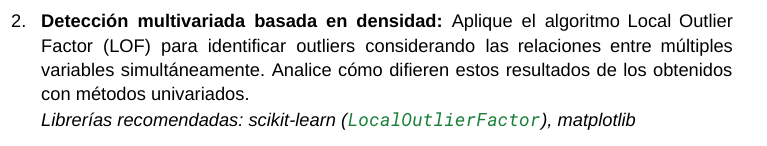